# Lab 6

You are tasked with evaluating card counting strategies for black jack. In order to do so, you will use object oriented programming to create a playable casino style black jack game where a computer dealer plays against $n$ computer players and possibily one human player. If you don't know the rules of blackjack or card counting, please google it. 

A few requirements:
* The game should utilize multiple 52-card decks. Typically the game is played with 6 decks.
* Players should have chips.
* Dealer's actions are predefined by rules of the game (typically hit on 16). 
* The players should be aware of all shown cards so that they can count cards.
* Each player could have a different strategy.
* The system should allow you to play large numbers of games, study the outcomes, and compare average winnings per hand rate for different strategies.

1. Begin by creating a classes to represent cards and decks. The deck should support more than one 52-card set. The deck should allow you to shuffle and draw cards. Include a "plastic" card, placed randomly in the deck. Later, when the plastic card is dealt, shuffle the cards before the next deal.

In [2]:
import random

class Card:
    suits = ["Hearts", "Diamonds", "Clubs", "Spades"]
    ranks = ["2","3","4","5","6","7","8","9","10","J","Q","K","A"]
    values = {
        "2":2,"3":3,"4":4,"5":5,"6":6,
        "7":7,"8":8,"9":9,"10":10,
        "J":10,"Q":10,"K":10,"A":11
    }

    def __init__(self, suit, rank):
        self.suit = suit
        self.rank = rank
        self.value = Card.values[rank]

    def __repr__(self):
        return f"{self.rank} of {self.suit}"


class Deck:
    def __init__(self, n_decks=6):
        self.n_decks = n_decks
        self.cards = []
        self.cut_card_position = None
        self.cut_card_reached = False
        self.build_deck()
        self.shuffle()

    def build_deck(self):
        self.cards = []
        for _ in range(self.n_decks):
            for suit in Card.suits:
                for rank in Card.ranks:
                    self.cards.append(Card(suit, rank))

        deck_size = len(self.cards)
        # Place plastic card randomly in the bottom 25-40% of the shoe
        self.cut_card_position = random.randint(
            int(deck_size * 0.25), int(deck_size * 0.40)
        )

    def shuffle(self):
        random.shuffle(self.cards)
        self.cut_card_reached = False

    def draw(self):
        if len(self.cards) == 0:
            raise ValueError("No cards left")
        # Plastic card triggers when remaining cards fall to cut position
        if len(self.cards) <= self.cut_card_position:
            self.cut_card_reached = True
        return self.cards.pop()

    def needs_shuffle(self):
        return self.cut_card_reached

    def cards_remaining(self):
        return len(self.cards)

In [3]:
deck = Deck(n_decks=6)

for _ in range(5):
    print(deck.draw())

print("Cards remaining:", deck.cards_remaining())

J of Clubs
2 of Diamonds
5 of Diamonds
6 of Spades
4 of Clubs
Cards remaining: 307


2. Now design your game on a UML diagram. You may want to create classes to represent, players, a hand, and/or the game. As you work through the lab, update your UML diagram. At the end of the lab, submit your diagram (as pdf file) along with your notebook.

3. Begin with implementing the skeleton (ie define data members and methods/functions, but do not code the logic) of the classes in your UML diagram.

In [4]:
import random

class Card:
    suits = ["Hearts", "Diamonds", "Clubs", "Spades"]
    ranks = ["2","3","4","5","6","7","8","9","10","J","Q","K","A"]
    values = {
        "2":2,"3":3,"4":4,"5":5,"6":6,
        "7":7,"8":8,"9":9,"10":10,
        "J":10,"Q":10,"K":10,"A":11
    }

    def __init__(self, suit, rank):
        self.suit = None
        self.rank = None
        self.value = None

    def __repr__(self):
        pass


class Deck:
    def __init__(self, n_decks=6):
        self.n_decks = None
        self.cards = None
        self.cut_card_position = None
        self.cut_card_reached = None

    def build_deck(self):
        pass

    def shuffle(self):
        pass

    def draw(self):
        pass

    def needs_shuffle(self):
        pass

    def cards_remaining(self):
        pass


class Hand:
    def __init__(self):
        self.cards = None

    def add_card(self, card):
        pass

    def value(self):
        pass

    def is_blackjack(self):
        pass

    def is_bust(self):
        pass

    def __repr__(self):
        pass


class Player:
    def __init__(self, chips=100):
        self.chips = None
        self.hand = None

    def bet(self):
        pass

    def play_turn(self, deck):
        pass

    def update_chips(self, amount):
        pass


class DealerPlayer:
    def __init__(self, name, chips=100):
        self.name = None
        self.chips = None
        self.hand = None

    def bet(self):
        pass

    def play_turn(self, deck):
        pass

    def update_chips(self, amount):
        pass

class Dealer:
    def __init__(self):
        self.hand = None

    def show_upcard(self):
        pass

    def play_turn(self, deck):
        pass


class Game:
    def __init__(self, n_decks=6):
        self.deck = None
        self.players = None
        self.dealer = None

    def start_round(self):
        pass

    def deal_initial_cards(self):
        # Deals 2 cards to each player and dealer.
        # Players see all player cards + dealer upcard only.
        # Dealer hole card stays hidden until dealer's turn.
        pass

    def resolve(self, player, bet):
        pass

    def play_round(self):
        # After dealer plays, card counters update count
        # with the revealed hole card.
        pass

4. Complete the implementation by coding the logic of all functions. For now, just implement the dealer player and human player.

In [5]:
import random

class Card:
    suits = ["Hearts", "Diamonds", "Clubs", "Spades"]
    ranks = ["2","3","4","5","6","7","8","9","10","J","Q","K","A"]
    values = {
        "2":2,"3":3,"4":4,"5":5,"6":6,
        "7":7,"8":8,"9":9,"10":10,
        "J":10,"Q":10,"K":10,"A":11
    }

    def __init__(self, suit, rank):
        self.suit = suit
        self.rank = rank
        self.value = Card.values[rank]

    def __repr__(self):
        return f"{self.rank} of {self.suit}"


class Deck:
    def __init__(self, n_decks=6):
        self.n_decks = n_decks
        self.cards = []
        self.cut_card_position = None
        self.cut_card_reached = False
        self.build_deck()
        self.shuffle()

    def build_deck(self):
        self.cards = []
        for _ in range(self.n_decks):
            for suit in Card.suits:
                for rank in Card.ranks:
                    self.cards.append(Card(suit, rank))
        deck_size = len(self.cards)
        self.cut_card_position = random.randint(
            int(deck_size * 0.25), int(deck_size * 0.40)
        )

    def shuffle(self):
        random.shuffle(self.cards)
        self.cut_card_reached = False

    def draw(self):
        if len(self.cards) == 0:
            raise ValueError("No cards left")
        if len(self.cards) <= self.cut_card_position:
            self.cut_card_reached = True
        return self.cards.pop()

    def needs_shuffle(self):
        return self.cut_card_reached

    def cards_remaining(self):
        return len(self.cards)


class Hand:
    def __init__(self):
        self.cards = []

    def add_card(self, card):
        self.cards.append(card)

    def value(self):
        total = 0
        aces = 0
        for card in self.cards:
            total += card.value
            if card.rank == "A":
                aces += 1
        while total > 21 and aces > 0:
            total -= 10
            aces -= 1
        return total

    def is_blackjack(self):
        return len(self.cards) == 2 and self.value() == 21

    def is_bust(self):
        return self.value() > 21

    def __repr__(self):
        return f"{self.cards} (value={self.value()})"


class Player:
    def __init__(self, chips=100):
        self.name = "Human"
        self.chips = chips
        self.hand = Hand()

    def bet(self):
        while True:
            try:
                amount = int(input(f"\n[{self.name}] You have {self.chips} chips. Bet: "))
                if 0 < amount <= self.chips:
                    return amount
                print("Bet must be between 1 and your chip total.")
            except ValueError:
                print("Please enter a valid number.")

    def play_turn(self, deck):
        print(f"\n[{self.name}] Your hand: {self.hand}")
        while not self.hand.is_bust():
            move = input("Hit or Stand? (h/s): ").strip().lower()
            if move == "h":
                card = deck.draw()
                self.hand.add_card(card)
                print(f"  Drew: {card} | Hand: {self.hand}")
            elif move == "s":
                print(f"  Standing on {self.hand.value()}")
                break
            else:
                print("  Please enter h or s.")
        if self.hand.is_bust():
            print(f"  Bust! ({self.hand.value()})")

    def update_chips(self, amount):
        self.chips += amount


class DealerPlayer:
    def __init__(self, name, chips=100):
        self.name = name
        self.chips = chips
        self.hand = Hand()

    def bet(self):
        return 10  # fixed bet

    def play_turn(self, deck):
        # Mirrors dealer rules: hit below 17, stand at 17+
        while self.hand.value() < 17:
            self.hand.add_card(deck.draw())

    def update_chips(self, amount):
        self.chips += amount


class Dealer:
    def __init__(self):
        self.hand = Hand()

    def show_upcard(self):
        return self.hand.cards[0]

    def play_turn(self, deck):
        while self.hand.value() < 17:
            self.hand.add_card(deck.draw())


class Game:
    def __init__(self, n_decks=6, players=None):
        self.deck = Deck(n_decks)
        self.players = players if players is not None else [Player()]
        self.dealer = Dealer()

    def start_round(self):
        if self.deck.needs_shuffle():
            print("\n--- Reshuffling deck ---")
            self.deck.build_deck()
            self.deck.shuffle()
        for player in self.players:
            player.hand = Hand()
        self.dealer.hand = Hand()

    def deal_initial_cards(self):
        # Deal 2 cards to each player and the dealer
        for _ in range(2):
            for player in self.players:
                player.hand.add_card(self.deck.draw())
            self.dealer.hand.add_card(self.deck.draw())

        print(f"\nDealer shows: {self.dealer.show_upcard()} [hole card hidden]")
        for player in self.players:
            print(f"[{player.name}] hand: {player.hand}")

    def resolve(self, player, bet):
        pv = player.hand.value()
        dv = self.dealer.hand.value()

        if player.hand.is_blackjack() and not self.dealer.hand.is_blackjack():
            print(f"  [{player.name}] Blackjack! Wins 3:2")
            player.update_chips(int(bet * 1.5))
        elif self.dealer.hand.is_blackjack() and not player.hand.is_blackjack():
            print(f"  [{player.name}] Dealer blackjack. Loses.")
            player.update_chips(-bet)
        elif player.hand.is_bust():
            print(f"  [{player.name}] Bust. Loses.")
            player.update_chips(-bet)
        elif self.dealer.hand.is_bust():
            print(f"  [{player.name}] Dealer bust. Wins.")
            player.update_chips(bet)
        elif pv > dv:
            print(f"  [{player.name}] Wins ({pv} vs {dv})")
            player.update_chips(bet)
        elif pv < dv:
            print(f"  [{player.name}] Loses ({pv} vs {dv})")
            player.update_chips(-bet)
        else:
            print(f"  [{player.name}] Push ({pv} vs {dv})")

        print(f"  [{player.name}] Chips: {player.chips}")

    def play_round(self):
        self.start_round()

        bets = {p.name: p.bet() for p in self.players}

        self.deal_initial_cards()

        for player in self.players:
            player.play_turn(self.deck)

        if any(not p.hand.is_bust() for p in self.players):
            self.dealer.play_turn(self.deck)

        print(f"\nDealer final hand: {self.dealer.hand}")
        print("\n--- Results ---")
        for player in self.players:
            self.resolve(player, bets[player.name])


# -------------------------
# Run Game
# -------------------------

players = [
    Player(chips=100),
    DealerPlayer(name="Bot1", chips=100),
    DealerPlayer(name="Bot2", chips=100),
]

game = Game(n_decks=6, players=players)

while True:
    game.play_round()
    again = input("\nPlay another round? (y/n): ").strip().lower()
    if again != "y":
        break


Dealer shows: K of Hearts [hole card hidden]
[Human] hand: [8 of Spades, 8 of Hearts] (value=16)
[Bot1] hand: [9 of Hearts, Q of Diamonds] (value=19)
[Bot2] hand: [Q of Spades, 9 of Spades] (value=19)

[Human] Your hand: [8 of Spades, 8 of Hearts] (value=16)
  Drew: J of Spades | Hand: [8 of Spades, 8 of Hearts, J of Spades] (value=26)
  Bust! (26)

Dealer final hand: [K of Hearts, 4 of Hearts, K of Diamonds] (value=24)

--- Results ---
  [Human] Bust. Loses.
  [Human] Chips: 50
  [Bot1] Dealer bust. Wins.
  [Bot1] Chips: 110
  [Bot2] Dealer bust. Wins.
  [Bot2] Chips: 110


5.  Test. Demonstrate game play. For example, create a game of several dealer players and show that the game is functional through several rounds.

In [6]:
# -------------------------
# Test: 3 Dealer Bots, 5 Rounds
# -------------------------

players = [
    DealerPlayer(name="Bot1", chips=100),
    DealerPlayer(name="Bot2", chips=100),
    DealerPlayer(name="Bot3", chips=100),
]

game = Game(n_decks=6, players=players)

N_ROUNDS = 5

print("=" * 50)
print("  BLACKJACK SIMULATION — 3 Bots, 5 Rounds")
print("=" * 50)

for round_num in range(1, N_ROUNDS + 1):
    print(f"\n{'='*50}")
    print(f"  ROUND {round_num}")
    print(f"{'='*50}")
    game.play_round()

print(f"\n{'='*50}")
print("  FINAL CHIP COUNTS")
print(f"{'='*50}")
for player in game.players:
    net = player.chips - 100
    print(f"  {player.name}: {player.chips} chips (net: {net:+d})")

  BLACKJACK SIMULATION — 3 Bots, 5 Rounds

  ROUND 1

Dealer shows: 2 of Diamonds [hole card hidden]
[Bot1] hand: [6 of Diamonds, 10 of Clubs] (value=16)
[Bot2] hand: [J of Spades, 3 of Spades] (value=13)
[Bot3] hand: [A of Hearts, 10 of Diamonds] (value=21)

Dealer final hand: [2 of Diamonds, Q of Spades, 5 of Diamonds] (value=17)

--- Results ---
  [Bot1] Bust. Loses.
  [Bot1] Chips: 90
  [Bot2] Wins (18 vs 17)
  [Bot2] Chips: 110
  [Bot3] Blackjack! Wins 3:2
  [Bot3] Chips: 115

  ROUND 2

Dealer shows: A of Diamonds [hole card hidden]
[Bot1] hand: [Q of Spades, Q of Diamonds] (value=20)
[Bot2] hand: [7 of Hearts, K of Diamonds] (value=17)
[Bot3] hand: [4 of Clubs, 7 of Hearts] (value=11)

Dealer final hand: [A of Diamonds, 9 of Clubs] (value=20)

--- Results ---
  [Bot1] Push (20 vs 20)
  [Bot1] Chips: 90
  [Bot2] Loses (17 vs 20)
  [Bot2] Chips: 100
  [Bot3] Loses (17 vs 20)
  [Bot3] Chips: 105

  ROUND 3

Dealer shows: 8 of Spades [hole card hidden]
[Bot1] hand: [7 of Diamonds, K

6. Implement a new player with the following strategy:

    * Assign each card a value: 
        * Cards 2 to 6 are +1 
        * Cards 7 to 9 are 0 
        * Cards 10 through Ace are -1
    * Compute the sum of the values for all cards seen so far.
    * Hit if sum is very negative, stay if sum is very positive. Select a threshold for hit/stay, e.g. 0 or -2.

In [7]:
##The card counting player has to be aware of all the cards shown so that information has to be passed to the class.


class CardCountingPlayer_1:

    def __init__(self, name, threshold=-2, chips=100):
        self.name = name
        self.threshold = threshold
        self.chips = chips
        self.hand = Hand()
        self.running_count = 0

    def card_value(self, card):
        if card.rank in ["2", "3", "4", "5", "6"]:
            return 1
        elif card.rank in ["7", "8", "9"]:
            return 0
        else:  # 10, J, Q, K, A
            return -1

    def update_count(self, cards):
        for card in cards:
            self.running_count += self.card_value(card)

    def bet(self):
        return 10

    def play_turn(self, deck):
        while not self.hand.is_bust():
            if self.running_count < self.threshold:
                card = deck.draw()
                self.hand.add_card(card)
                self.update_count([card])
            else:
                break

    def update_chips(self, amount):
        self.chips += amount


In [16]:
# Update Game.deal_initial_cards to feed card counters
class Game:
    def __init__(self, n_decks=6, players=None):
        self.deck = Deck(n_decks)
        self.players = players if players is not None else [Player()]
        self.dealer = Dealer()

    def start_round(self):
        if self.deck.needs_shuffle():
            print("\n--- Reshuffling deck ---")
            self.deck.build_deck()
            self.deck.shuffle()
            for p in self.players:
                if isinstance(p, CardCountingPlayer):
                    p.running_count = 0  # reset count on new shoe
        for player in self.players:
            player.hand = Hand()
        self.dealer.hand = Hand()

    def deal_initial_cards(self):
        for _ in range(2):
            for player in self.players:
                card = self.deck.draw()
                player.hand.add_card(card)
                # All counters observe every player card
                for p in self.players:
                    if isinstance(p, CardCountingPlayer_1):
                        p.update_count([card])
            dealer_card = self.deck.draw()
            self.dealer.hand.add_card(dealer_card)
        # Counters see dealer upcard only — hole card stays hidden
        for p in self.players:
            if isinstance(p, CardCountingPlayer_1):
                p.update_count([self.dealer.hand.cards[0]])

        print(f"\nDealer shows: {self.dealer.show_upcard()} [hole card hidden]")
        for player in self.players:
            print(f"[{player.name}] hand: {player.hand}")

    def resolve(self, player, bet):
        pv = player.hand.value()
        dv = self.dealer.hand.value()

        if player.hand.is_blackjack() and not self.dealer.hand.is_blackjack():
            print(f"  [{player.name}] Blackjack! Wins 3:2")
            player.update_chips(int(bet * 1.5))
        elif self.dealer.hand.is_blackjack() and not player.hand.is_blackjack():
            print(f"  [{player.name}] Dealer blackjack. Loses.")
            player.update_chips(-bet)
        elif player.hand.is_bust():
            print(f"  [{player.name}] Bust. Loses.")
            player.update_chips(-bet)
        elif self.dealer.hand.is_bust():
            print(f"  [{player.name}] Dealer bust. Wins.")
            player.update_chips(bet)
        elif pv > dv:
            print(f"  [{player.name}] Wins ({pv} vs {dv})")
            player.update_chips(bet)
        elif pv < dv:
            print(f"  [{player.name}] Loses ({pv} vs {dv})")
            player.update_chips(-bet)
        else:
            print(f"  [{player.name}] Push ({pv} vs {dv})")

        print(f"  [{player.name}] Chips: {player.chips}")

    def play_round(self):
        self.start_round()
        bets = {p.name: p.bet() for p in self.players}
        self.deal_initial_cards()

        for p in self.players:
            if isinstance(p, CardCountingPlayer_1):
                print(f"\n[{p.name}] Running count: {p.running_count}")

        for player in self.players:
            player.play_turn(self.deck)

        if any(not p.hand.is_bust() for p in self.players):
            self.dealer.play_turn(self.deck)

        # Counters now see the revealed hole card
        for p in self.players:
            if isinstance(p, CardCountingPlayer_1):
                p.update_count([self.dealer.hand.cards[1]])

        print(f"\nDealer final hand: {self.dealer.hand}")
        print("\n--- Results ---")
        for player in self.players:
            self.resolve(player, bets[player.name])

In [17]:
# -------------------------
# Test: Counter vs 3 Bots, 5 Rounds
# -------------------------

players = [
    CardCountingPlayer_1(name="Counter", threshold=2, chips=100),
    DealerPlayer(name="Bot1", chips=100),
    DealerPlayer(name="Bot2", chips=100),
    DealerPlayer(name="Bot3", chips=100),
]

game = Game(n_decks=6, players=players)

N_ROUNDS = 5

print("=" * 50)
print("  BLACKJACK — Counter vs 3 Bots, 5 Rounds")
print("=" * 50)

for round_num in range(1, N_ROUNDS + 1):
    print(f"\n{'='*50}")
    print(f"  ROUND {round_num}")
    print(f"{'='*50}")
    game.play_round()

print(f"\n{'='*50}")
print("  FINAL CHIP COUNTS")
print(f"{'='*50}")
for player in game.players:
    net = player.chips - 100
    print(f"  {player.name}: {player.chips} chips (net: {net:+d})")

  BLACKJACK — Counter vs 3 Bots, 5 Rounds

  ROUND 1

Dealer shows: 9 of Hearts [hole card hidden]
[Counter] hand: [2 of Clubs, Q of Diamonds] (value=12)
[Bot1] hand: [J of Diamonds, 8 of Clubs] (value=18)
[Bot2] hand: [3 of Spades, 5 of Diamonds] (value=8)
[Bot3] hand: [4 of Spades, 2 of Hearts] (value=6)

[Counter] Running count: 3

Dealer final hand: [9 of Hearts, 10 of Spades] (value=19)

--- Results ---
  [Counter] Loses (12 vs 19)
  [Counter] Chips: 90
  [Bot1] Loses (18 vs 19)
  [Bot1] Chips: 90
  [Bot2] Loses (18 vs 19)
  [Bot2] Chips: 90
  [Bot3] Bust. Loses.
  [Bot3] Chips: 90

  ROUND 2

Dealer shows: 7 of Hearts [hole card hidden]
[Counter] hand: [10 of Clubs, 2 of Diamonds] (value=12)
[Bot1] hand: [2 of Clubs, 9 of Spades] (value=11)
[Bot2] hand: [A of Spades, K of Diamonds] (value=21)
[Bot3] hand: [Q of Diamonds, 5 of Diamonds] (value=15)

[Counter] Running count: 1

Dealer final hand: [7 of Hearts, K of Spades] (value=17)

--- Results ---
  [Counter] Bust. Loses.
  [Coun

7. Create a test scenario where one player, using the above strategy, is playing with a dealer and 3 other players that follow the dealer's strategy. Each player starts with same number of chips. Play 50 rounds (or until the strategy player is out of money). Compute the strategy player's winnings. You may remove unnecessary printouts from your code (perhaps implement a verbose/quiet mode) to reduce the output.

In [19]:
class SimGame:
    def __init__(self, n_decks=6, verbose=False):
        self.deck = Deck(n_decks)
        self.verbose = verbose
        self.counter = CardCountingPlayer_1(name="Counter", threshold=-2, chips=100)
        self.players = [
            self.counter,
            DealerPlayer(name="Bot1", chips=100),
            DealerPlayer(name="Bot2", chips=100),
            DealerPlayer(name="Bot3", chips=100),
        ]
        self.dealer = Dealer()

    def log(self, msg):
        if self.verbose:
            print(msg)

    def start_round(self):
        if self.deck.needs_shuffle():
            self.log("\n--- Reshuffling deck ---")
            self.deck.build_deck()
            self.deck.shuffle()
            self.counter.running_count = 0
        for p in self.players:
            p.hand = Hand()
        self.dealer.hand = Hand()

    def deal_initial_cards(self):
        for _ in range(2):
            for player in self.players:
                card = self.deck.draw()
                player.hand.add_card(card)
                for p in self.players:
                    if isinstance(p, CardCountingPlayer_1):
                        p.update_count([card])
            dealer_card = self.deck.draw()
            self.dealer.hand.add_card(dealer_card)
        # Counters see upcard only
        for p in self.players:
            if isinstance(p, CardCountingPlayer_1):
                p.update_count([self.dealer.hand.cards[0]])

        self.log(f"\nDealer shows: {self.dealer.hand.cards[0]} [hole card hidden]")
        for p in self.players:
            self.log(f"  [{p.name}] hand: {p.hand}")

    def resolve(self, player, bet):
        pv = player.hand.value()
        dv = self.dealer.hand.value()

        if player.hand.is_blackjack() and not self.dealer.hand.is_blackjack():
            player.update_chips(int(bet * 1.5))
            self.log(f"  [{player.name}] Blackjack! Wins 3:2")
        elif self.dealer.hand.is_blackjack() and not player.hand.is_blackjack():
            player.update_chips(-bet)
            self.log(f"  [{player.name}] Dealer blackjack. Loses.")
        elif player.hand.is_bust():
            player.update_chips(-bet)
            self.log(f"  [{player.name}] Bust. Loses.")
        elif self.dealer.hand.is_bust():
            player.update_chips(bet)
            self.log(f"  [{player.name}] Dealer bust. Wins.")
        elif pv > dv:
            player.update_chips(bet)
            self.log(f"  [{player.name}] Wins ({pv} vs {dv})")
        elif pv < dv:
            player.update_chips(-bet)
            self.log(f"  [{player.name}] Loses ({pv} vs {dv})")
        else:
            self.log(f"  [{player.name}] Push ({pv} vs {dv})")

    def play_round(self):
        self.start_round()
        bets = {p.name: p.bet() for p in self.players}

        self.log(f"\n[Counter] Running count: {self.counter.running_count}")

        self.deal_initial_cards()

        for p in self.players:
            p.play_turn(self.deck)

        if any(not p.hand.is_bust() for p in self.players):
            self.dealer.play_turn(self.deck)

        # Reveal hole card to counters
        for p in self.players:
            if isinstance(p, CardCountingPlayer_1):
                p.update_count([self.dealer.hand.cards[1]])

        self.log(f"\nDealer final hand: {self.dealer.hand}")
        self.log("--- Results ---")
        for p in self.players:
            self.resolve(p, bets[p.name])

# -------------------------
# Run Scenario
# -------------------------

STARTING_CHIPS = 100
MAX_ROUNDS     = 50

sim = SimGame(n_decks=6, verbose=False)

for round_num in range(1, MAX_ROUNDS + 1):
    if sim.counter.chips <= 0:
        print(f"Counter ran out of chips after {round_num - 1} rounds.")
        break
    sim.play_round()
else:
    print(f"Completed {MAX_ROUNDS} rounds.")

net = sim.counter.chips - STARTING_CHIPS
print(f"Counter final chips : {sim.counter.chips}")
print(f"Counter net winnings: {net:+d}")
print(f"\nAll players final chips:")
for p in sim.players:
    print(f"  {p.name}: {p.chips} ({p.chips - STARTING_CHIPS:+d})")

Counter ran out of chips after 19 rounds.
Counter final chips : 0
Counter net winnings: -100

All players final chips:
  Counter: 0 (-100)
  Bot1: 20 (-80)
  Bot2: 100 (+0)
  Bot3: 85 (-15)


8. Create a loop that runs 100 games of 50 rounds, as setup in previous question, and store the strategy player's chips at the end of the game (aka "winnings") in a list. Histogram the winnings. What is the average winnings per round? What is the standard deviation. What is the probabilty of net winning or lossing after 50 rounds?


Average total winnings:    -91.35 chips
Average winnings per round:-1.8270 chips
Standard deviation:        29.82 chips
Probability of net win:    2.00%
Probability of net loss:   98.00%


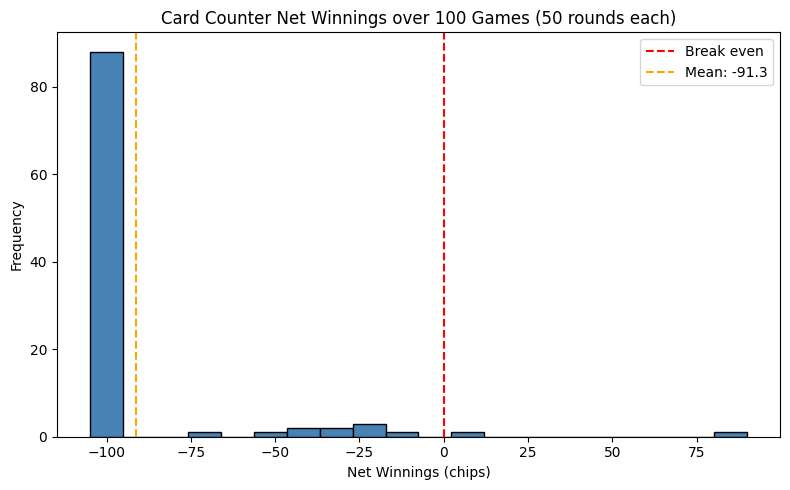

In [24]:
import numpy as np
import matplotlib.pyplot as plt

# -------------------------
# Run 100 Games
# -------------------------

STARTING_CHIPS = 100
MAX_ROUNDS     = 50
N_GAMES        = 100

final_chips = []

for _ in range(N_GAMES):
    sim = SimGame(n_decks=6, verbose=False)
    for _ in range(MAX_ROUNDS):
        if sim.counter.chips <= 0:
            break
        sim.play_round()
    final_chips.append(sim.counter.chips)

winnings = [c - STARTING_CHIPS for c in final_chips]

# -------------------------
# Statistics
# -------------------------

mean_w      = np.mean(winnings)
std_w       = np.std(winnings)
avg_round   = mean_w / MAX_ROUNDS
prob_win    = np.mean([w > 0 for w in winnings])
prob_loss   = np.mean([w < 0 for w in winnings])

print(f"Average total winnings:    {mean_w:+.2f} chips")
print(f"Average winnings per round:{avg_round:+.4f} chips")
print(f"Standard deviation:        {std_w:.2f} chips")
print(f"Probability of net win:    {prob_win:.2%}")
print(f"Probability of net loss:   {prob_loss:.2%}")

# -------------------------
# Histogram
# -------------------------

plt.figure(figsize=(8, 5))
plt.hist(winnings, bins=20, edgecolor='black', color='steelblue')
plt.axvline(0,      color='red',    linestyle='--', label='Break even')
plt.axvline(mean_w, color='orange', linestyle='--', label=f'Mean: {mean_w:.1f}')
plt.xlabel("Net Winnings (chips)")
plt.ylabel("Frequency")
plt.title("Card Counter Net Winnings over 100 Games (50 rounds each)")
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
## Only using the sum causes the player to hit on strong hands and stand on weak hands so we should implement a check for the card values as well

In [25]:
class CardCountingPlayer_2:

    def __init__(self, name, threshold=2, chips=100):
        self.name = name
        self.threshold = threshold
        self.chips = chips
        self.hand = Hand()
        self.running_count = 0

    def card_value(self, card):
        if card.rank in ["2", "3", "4", "5", "6"]:
            return 1
        elif card.rank in ["7", "8", "9"]:
            return 0
        else:  # 10, J, Q, K, A
            return -1

    def update_count(self, cards):
        for card in cards:
            self.running_count += self.card_value(card)

    def bet(self):
        return 10

    def play_turn(self, deck):
        while not self.hand.is_bust():
            hand_val = self.hand.value()
            # Always stand on strong hands
            if hand_val >= 17:
                break
            # Always hit on weak hands — can't bust
            if hand_val <= 11:
                card = deck.draw()
                self.hand.add_card(card)
                self.update_count([card])
            # For middle hands (12-16), use count signal
            elif self.running_count < self.threshold:
                card = deck.draw()
                self.hand.add_card(card)
                self.update_count([card])
            else:
                break

    def update_chips(self, amount):
        self.chips += amount

Testing the new counter with a check for the hand value

In [30]:
class SimGame:
    def __init__(self, n_decks=6, verbose=False):
        self.deck = Deck(n_decks)
        self.verbose = verbose
        self.counter = CardCountingPlayer_2(name="Counter", threshold=-2, chips=100)
        self.players = [
            self.counter,
            DealerPlayer(name="Bot1", chips=100),
            DealerPlayer(name="Bot2", chips=100),
            DealerPlayer(name="Bot3", chips=100),
        ]
        self.dealer = Dealer()

    def log(self, msg):
        if self.verbose:
            print(msg)

    def start_round(self):
        if self.deck.needs_shuffle():
            self.log("\n--- Reshuffling deck ---")
            self.deck.build_deck()
            self.deck.shuffle()
            self.counter.running_count = 0
        for p in self.players:
            p.hand = Hand()
        self.dealer.hand = Hand()

    def deal_initial_cards(self):
        for _ in range(2):
            for player in self.players:
                card = self.deck.draw()
                player.hand.add_card(card)
                for p in self.players:
                    if isinstance(p, CardCountingPlayer_2):
                        p.update_count([card])
            dealer_card = self.deck.draw()
            self.dealer.hand.add_card(dealer_card)
        # Counters see upcard only
        for p in self.players:
            if isinstance(p, CardCountingPlayer_2):
                p.update_count([self.dealer.hand.cards[0]])

        self.log(f"\nDealer shows: {self.dealer.hand.cards[0]} [hole card hidden]")
        for p in self.players:
            self.log(f"  [{p.name}] hand: {p.hand}")

    def resolve(self, player, bet):
        pv = player.hand.value()
        dv = self.dealer.hand.value()

        if player.hand.is_blackjack() and not self.dealer.hand.is_blackjack():
            player.update_chips(int(bet * 1.5))
            self.log(f"  [{player.name}] Blackjack! Wins 3:2")
        elif self.dealer.hand.is_blackjack() and not player.hand.is_blackjack():
            player.update_chips(-bet)
            self.log(f"  [{player.name}] Dealer blackjack. Loses.")
        elif player.hand.is_bust():
            player.update_chips(-bet)
            self.log(f"  [{player.name}] Bust. Loses.")
        elif self.dealer.hand.is_bust():
            player.update_chips(bet)
            self.log(f"  [{player.name}] Dealer bust. Wins.")
        elif pv > dv:
            player.update_chips(bet)
            self.log(f"  [{player.name}] Wins ({pv} vs {dv})")
        elif pv < dv:
            player.update_chips(-bet)
            self.log(f"  [{player.name}] Loses ({pv} vs {dv})")
        else:
            self.log(f"  [{player.name}] Push ({pv} vs {dv})")

    def play_round(self):
        self.start_round()
        bets = {p.name: p.bet() for p in self.players}

        self.log(f"\n[Counter] Running count: {self.counter.running_count}")

        self.deal_initial_cards()

        for p in self.players:
            p.play_turn(self.deck)

        if any(not p.hand.is_bust() for p in self.players):
            self.dealer.play_turn(self.deck)

        # Reveal hole card to counters
        for p in self.players:
            if isinstance(p, CardCountingPlayer_2):
                p.update_count([self.dealer.hand.cards[1]])

        self.log(f"\nDealer final hand: {self.dealer.hand}")
        self.log("--- Results ---")
        for p in self.players:
            self.resolve(p, bets[p.name])

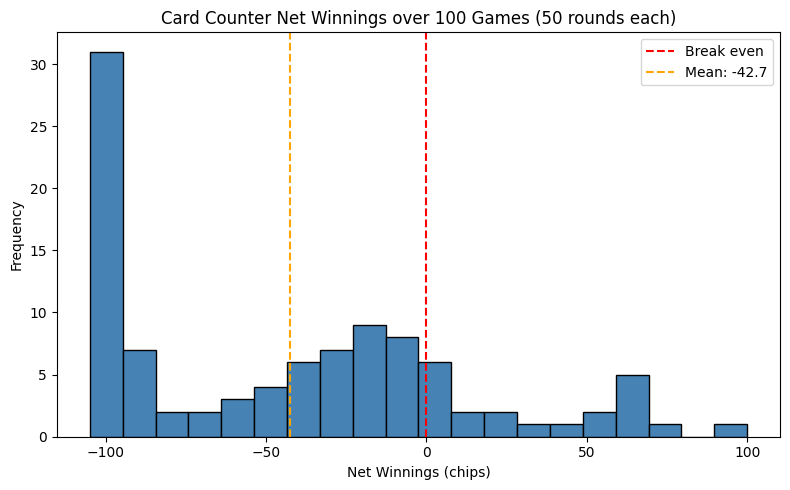

Average total winnings:    -42.70 chips
Average winnings per round:-0.8540 chips
Standard deviation:        53.70 chips
Probability of net win:    18.00%
Probability of net loss:   79.00%


In [31]:
# -------------------------
# Run 100 Games
# -------------------------

STARTING_CHIPS = 100
MAX_ROUNDS = 50
N_GAMES = 100

final_chips = []

for game_num in range(N_GAMES):
    sim = SimGame(n_decks=6)
    for round_num in range(MAX_ROUNDS):
        if sim.counter.chips <= 0:
            break
        sim.play_round()
    final_chips.append(sim.counter.chips)

winnings = [chips - STARTING_CHIPS for chips in final_chips]

# -------------------------
# Histogram
# -------------------------

plt.figure(figsize=(8, 5))
plt.hist(winnings, bins=20, edgecolor='black', color='steelblue')
plt.axvline(0, color='red', linestyle='--', label='Break even')
plt.axvline(np.mean(winnings), color='orange', linestyle='--', label=f'Mean: {np.mean(winnings):.1f}')
plt.xlabel("Net Winnings (chips)")
plt.ylabel("Frequency")
plt.title("Card Counter Net Winnings over 100 Games (50 rounds each)")
plt.legend()
plt.tight_layout()
plt.show()

# -------------------------
# Statistics
# -------------------------

mean_winnings     = np.mean(winnings)
std_winnings      = np.std(winnings)
avg_per_round     = mean_winnings / MAX_ROUNDS
prob_net_win      = np.mean([w > 0 for w in winnings])
prob_net_loss     = np.mean([w < 0 for w in winnings])

print(f"Average total winnings:    {mean_winnings:+.2f} chips")
print(f"Average winnings per round:{avg_per_round:+.4f} chips")
print(f"Standard deviation:        {std_winnings:.2f} chips")
print(f"Probability of net win:    {prob_net_win:.2%}")
print(f"Probability of net loss:   {prob_net_loss:.2%}")

We do see some improvement but the player still busts a lot of times

9. Repeat previous questions scanning the value of the threshold. Try at least 5 different threshold values. Can you find an optimal value?

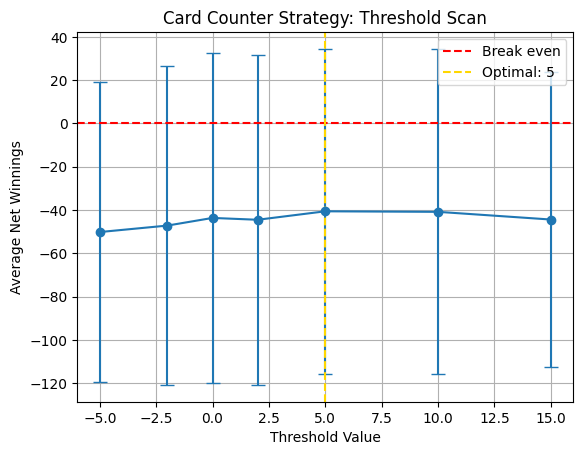

Optimal threshold:                    5
Avg net winnings at optimal threshold: -40.57


In [32]:
# -------------------------
# Threshold Scan
# -------------------------

thresholds     = [-5, -2, 0, 2, 5, 10, 15]
N_GAMES        = 500
MAX_ROUNDS     = 100
STARTING_CHIPS = 100

avg_winnings = []
std_winnings = []

for thresh in thresholds:
    final_chips = []
    for _ in range(N_GAMES):
        sim = SimGame(n_decks=6, verbose=False)
        sim.counter.threshold = thresh
        for _ in range(MAX_ROUNDS):
            if sim.counter.chips <= 0:
                break
            sim.play_round()
        final_chips.append(sim.counter.chips)

    net_winnings = [c - STARTING_CHIPS for c in final_chips]
    avg_winnings.append(np.mean(net_winnings))
    std_winnings.append(np.std(net_winnings))

# -------------------------
# Plot
# -------------------------

best_index = np.argmax(avg_winnings)
best_threshold = thresholds[best_index]

plt.errorbar(thresholds, avg_winnings, yerr=std_winnings, fmt='o-', capsize=5)
plt.axhline(0, color='red', linestyle='--', label='Break even')
plt.axvline(best_threshold, color='gold', linestyle='--', label=f'Optimal: {best_threshold}')
plt.xlabel("Threshold Value")
plt.ylabel("Average Net Winnings")
plt.title("Card Counter Strategy: Threshold Scan")
plt.legend()
plt.grid(True)
plt.show()

print(f"Optimal threshold:                    {best_threshold}")
print(f"Avg net winnings at optimal threshold: {avg_winnings[best_index]:+.2f}")

10. Create a new strategy based on web searches or your own ideas. Demonstrate that the new strategy will result in increased or decreased winnings.

Upon a quick web search another method for card counting in black jack is the true count method combined with dynamic betting. Ture count is the running count divided by the deck size. Dymaic betting is changing the bet size with the true count.

In [47]:
class TrueCountPlayer:
    def __init__(self, name, threshold=0, chips=100, n_decks=6):
        self.name = name
        self.threshold = threshold
        self.chips = chips
        self.hand = Hand()
        self.running_count = 0
        self.cards_seen = 0
        self.n_decks = n_decks
        self.total_cards = n_decks * 52

    def card_value(self, card):
        if card.rank in ["2", "3", "4", "5", "6"]:
            return 1
        elif card.rank in ["7", "8", "9"]:
            return 0
        else:
            return -1

    def update_count(self, cards):
        for card in cards:
            self.running_count += self.card_value(card)
            self.cards_seen += 1

    def true_count(self):
        cards_remaining = max(self.total_cards - self.cards_seen, 26)
        decks_remaining = cards_remaining / 52
        return self.running_count / decks_remaining

    def reset_count(self):
        self.running_count = 0
        self.cards_seen = 0
        self.total_cards = self.n_decks * 52

    def bet(self):
        tc = self.true_count()
        base   = 10
        scaled = base + max(0, int((tc - 1) * 5))
        capped = min(scaled, int(self.chips * 0.20))
        return max(5, min(capped, self.chips))

    def play_turn(self, deck):
        while not self.hand.is_bust():
            hand_val = self.hand.value()
            # Always stand on 17+
            if hand_val >= 17:
                break
            # Always hit on 11 or below — cannot bust
            if hand_val <= 11:
                card = deck.draw()
                self.hand.add_card(card)
                self.update_count([card])
            # For 12-16 use true count signal
            elif self.true_count() < self.threshold:
                card = deck.draw()
                self.hand.add_card(card)
                self.update_count([card])
            else:
                break

    def update_chips(self, amount):
        self.chips += amount

In [48]:
def start_round(self):
    if self.deck.needs_shuffle():
        self.deck.build_deck()
        self.deck.shuffle()
        if hasattr(self.counter, 'reset_count'):
            self.counter.reset_count()
        else:
            self.counter.running_count = 0
    for p in self.players:
        p.hand = Hand()
    self.dealer.hand = Hand()


--- Basic Counter ---
  Avg total winnings:    -24.00
  Avg winnings / round:  -0.4800
  Std deviation:         60.92
  P(net win):            32.00%
  P(net loss):           66.00%

--- True Count + Dynamic Bet ---
  Avg total winnings:    -24.63
  Avg winnings / round:  -0.4926
  Std deviation:         58.45
  P(net win):            31.00%
  P(net loss):           68.00%


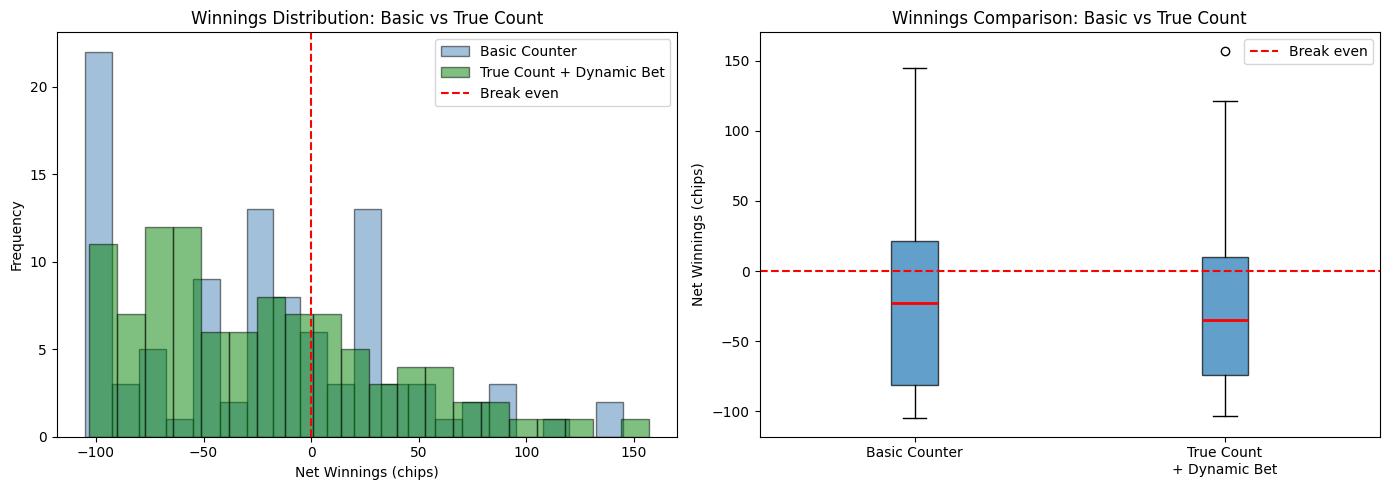

In [49]:
# -------------------------
# SimGame accepting any counter type
# -------------------------

class SimGame:
    def __init__(self, n_decks=6, verbose=False, counter=None):
        self.n_decks = n_decks
        self.deck = Deck(n_decks)
        self.verbose = verbose
        self.counter = counter if counter is not None else CardCountingPlayer(
            name="Counter", threshold=2, chips=100
        )
        self.players = [
            self.counter,
            DealerPlayer(name="Bot1", chips=100),
            DealerPlayer(name="Bot2", chips=100),
            DealerPlayer(name="Bot3", chips=100),
        ]
        self.dealer = Dealer()

    def log(self, msg):
        if self.verbose:
            print(msg)

    def start_round(self):
        if self.deck.needs_shuffle():
            self.log("\n--- Reshuffling deck ---")
            self.deck.build_deck()
            self.deck.shuffle()
            if hasattr(self.counter, 'reset_count'):
                self.counter.reset_count()
            else:
                self.counter.running_count = 0
        for p in self.players:
            p.hand = Hand()
        self.dealer.hand = Hand()

    def deal_initial_cards(self):
        for _ in range(2):
            for player in self.players:
                card = self.deck.draw()
                player.hand.add_card(card)
                self.counter.update_count([card])
            dealer_card = self.deck.draw()
            self.dealer.hand.add_card(dealer_card)
        self.counter.update_count([self.dealer.hand.cards[0]])

    def resolve(self, player, bet):
        pv = player.hand.value()
        dv = self.dealer.hand.value()
        if player.hand.is_blackjack() and not self.dealer.hand.is_blackjack():
            player.update_chips(int(bet * 1.5))
        elif self.dealer.hand.is_blackjack() and not player.hand.is_blackjack():
            player.update_chips(-bet)
        elif player.hand.is_bust():
            player.update_chips(-bet)
        elif self.dealer.hand.is_bust():
            player.update_chips(bet)
        elif pv > dv:
            player.update_chips(bet)
        elif pv < dv:
            player.update_chips(-bet)

    def play_round(self):
        self.start_round()
        bets = {p.name: p.bet() for p in self.players}
        self.deal_initial_cards()
        for p in self.players:
            p.play_turn(self.deck)
        if any(not p.hand.is_bust() for p in self.players):
            self.dealer.play_turn(self.deck)
        self.counter.update_count([self.dealer.hand.cards[1]])
        for p in self.players:
            self.resolve(p, bets[p.name])


# -------------------------
# Compare: CardCountingPlayer vs TrueCountPlayer
# -------------------------

N_GAMES        = 100
MAX_ROUNDS     = 50
STARTING_CHIPS = 100


def run_simulation(counter_class, threshold, n_games, max_rounds, n_decks=6):
    final_chips = []
    for _ in range(n_games):
        if counter_class == TrueCountPlayer:
            counter = counter_class(name="Counter", threshold=threshold,
                                    chips=STARTING_CHIPS, n_decks=n_decks)
        else:
            counter = counter_class(name="Counter", threshold=threshold,
                                    chips=STARTING_CHIPS)
        sim = SimGame(n_decks=n_decks, verbose=False, counter=counter)
        for _ in range(max_rounds):
            if sim.counter.chips <= 0:
                break
            sim.play_round()
        final_chips.append(sim.counter.chips)
    return [c - STARTING_CHIPS for c in final_chips]


basic_winnings = run_simulation(CardCountingPlayer_2, threshold=2, n_games=N_GAMES, max_rounds=MAX_ROUNDS)
true_winnings  = run_simulation(TrueCountPlayer,    threshold=2, n_games=N_GAMES, max_rounds=MAX_ROUNDS)

# -------------------------
# Plot comparison
# -------------------------

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for winnings, label, color in [
    (basic_winnings, "Basic Counter",            "steelblue"),
    (true_winnings,  "True Count + Dynamic Bet", "green"),
]:
    mean_w    = np.mean(winnings)
    std_w     = np.std(winnings)
    prob_win  = np.mean([w > 0 for w in winnings])
    prob_loss = np.mean([w < 0 for w in winnings])
    print(f"\n--- {label} ---")
    print(f"  Avg total winnings:    {mean_w:+.2f}")
    print(f"  Avg winnings / round:  {mean_w/MAX_ROUNDS:+.4f}")
    print(f"  Std deviation:         {std_w:.2f}")
    print(f"  P(net win):            {prob_win:.2%}")
    print(f"  P(net loss):           {prob_loss:.2%}")
    axes[0].hist(winnings, bins=20, alpha=0.5, edgecolor='black', label=label, color=color)

axes[0].axvline(0, color='red', linestyle='--', label='Break even')
axes[0].set_xlabel("Net Winnings (chips)")
axes[0].set_ylabel("Frequency")
axes[0].set_title("Winnings Distribution: Basic vs True Count")
axes[0].legend()

axes[1].boxplot(
    [basic_winnings, true_winnings],
    tick_labels=["Basic Counter", "True Count\n+ Dynamic Bet"],
    patch_artist=True,
    boxprops=dict(alpha=0.7),
    medianprops=dict(color="red", linewidth=2),
)
axes[1].axhline(0, color='red', linestyle='--', label='Break even')
axes[1].set_ylabel("Net Winnings (chips)")
axes[1].set_title("Winnings Comparison: Basic vs True Count")
axes[1].legend()

plt.tight_layout()
plt.show()